In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# FCN trained on male cohort

In [2]:
config_path = "../configs/fcn_m.yaml"

In [3]:
config = load_config(config_path)
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
_, val_loader_f, test_loader_f = dataset_f.get_loaders()

dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
_, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [4]:
trainer = build_trainer(config)
trainer.load_checkpoint()

## Testing with simillar threshold

In [5]:
best_thr = trainer.choose_threshold(val_loader)

/home/maryna/anaconda3/envs/compmed/lib/python3.9/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv1d(


Best threshold: 0.323
Sensitivity: 0.918
Specificity: 0.813
AUC: 0.945
Accuracy: 0.865


In [6]:
print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)


===== ALL =====
           TEST RESULTS
  Threshold         : 0.323
  AUC               : 0.9280
  Accuracy          : 0.8420
  Sensitivity       : 0.8684  (recall on MI)
  Specificity       : 0.8154  (recall on NORM)
  Precision         : 0.8260
  F1 Score          : 0.8467
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     614        139
  True MI    :     100        660
              precision    recall  f1-score   support

        NORM       0.86      0.82      0.84       753
          MI       0.83      0.87      0.85       760

    accuracy                           0.84      1513
   macro avg       0.84      0.84      0.84      1513
weighted avg       0.84      0.84      0.84      1513



In [7]:
print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)


===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.323
  AUC               : 0.9364
  Accuracy          : 0.8586
  Sensitivity       : 0.9041  (recall on MI)
  Specificity       : 0.8090  (recall on NORM)
  Precision         : 0.8376
  F1 Score          : 0.8696
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     271         64
  True MI    :      35        330
              precision    recall  f1-score   support

        NORM       0.89      0.81      0.85       335
          MI       0.84      0.90      0.87       365

    accuracy                           0.86       700
   macro avg       0.86      0.86      0.86       700
weighted avg       0.86      0.86      0.86       700



In [8]:
print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)


===== MALE =====
           TEST RESULTS
  Threshold         : 0.323
  AUC               : 0.9444
  Accuracy          : 0.8622
  Sensitivity       : 0.9059  (recall on MI)
  Specificity       : 0.8191  (recall on NORM)
  Precision         : 0.8318
  F1 Score          : 0.8673
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     335         74
  True MI    :      38        366
              precision    recall  f1-score   support

        NORM       0.90      0.82      0.86       409
          MI       0.83      0.91      0.87       404

    accuracy                           0.86       813
   macro avg       0.86      0.86      0.86       813
weighted avg       0.87      0.86      0.86       813



## Choosing best threshold separately for G, M and F

In [9]:
best_thr = trainer.choose_threshold(val_loader)

print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)

Best threshold: 0.292
Sensitivity: 0.903
Specificity: 0.812
AUC: 0.947
Accuracy: 0.856

===== ALL =====
           TEST RESULTS
  Threshold         : 0.292
  AUC               : 0.9411
  Accuracy          : 0.8519
  Sensitivity       : 0.8920  (recall on MI)
  Specificity       : 0.8126  (recall on NORM)
  Precision         : 0.8239
  F1 Score          : 0.8566
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     620        143
  True MI    :      81        669
              precision    recall  f1-score   support

        NORM       0.88      0.81      0.85       763
          MI       0.82      0.89      0.86       750

    accuracy                           0.85      1513
   macro avg       0.85      0.85      0.85      1513
weighted avg       0.85      0.85      0.85      1513



In [10]:
best_thr = trainer.choose_threshold(val_loader_f)

print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)

Best threshold: 0.260
Sensitivity: 0.905
Specificity: 0.813
AUC: 0.940
Accuracy: 0.856

===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.260
  AUC               : 0.9156
  Accuracy          : 0.8257
  Sensitivity       : 0.9000  (recall on MI)
  Specificity       : 0.7375  (recall on NORM)
  Precision         : 0.8028
  F1 Score          : 0.8486
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     236         84
  True MI    :      38        342
              precision    recall  f1-score   support

        NORM       0.86      0.74      0.79       320
          MI       0.80      0.90      0.85       380

    accuracy                           0.83       700
   macro avg       0.83      0.82      0.82       700
weighted avg       0.83      0.83      0.82       700



In [11]:
best_thr = trainer.choose_threshold(val_loader_m)

print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)

Best threshold: 0.323
Sensitivity: 0.905
Specificity: 0.802
AUC: 0.937
Accuracy: 0.854

===== MALE =====
           TEST RESULTS
  Threshold         : 0.323
  AUC               : 0.9452
  Accuracy          : 0.8610
  Sensitivity       : 0.8956  (recall on MI)
  Specificity       : 0.8220  (recall on NORM)
  Precision         : 0.8502
  F1 Score          : 0.8723
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     314         68
  True MI    :      45        386
              precision    recall  f1-score   support

        NORM       0.87      0.82      0.85       382
          MI       0.85      0.90      0.87       431

    accuracy                           0.86       813
   macro avg       0.86      0.86      0.86       813
weighted avg       0.86      0.86      0.86       813



### ROC curves

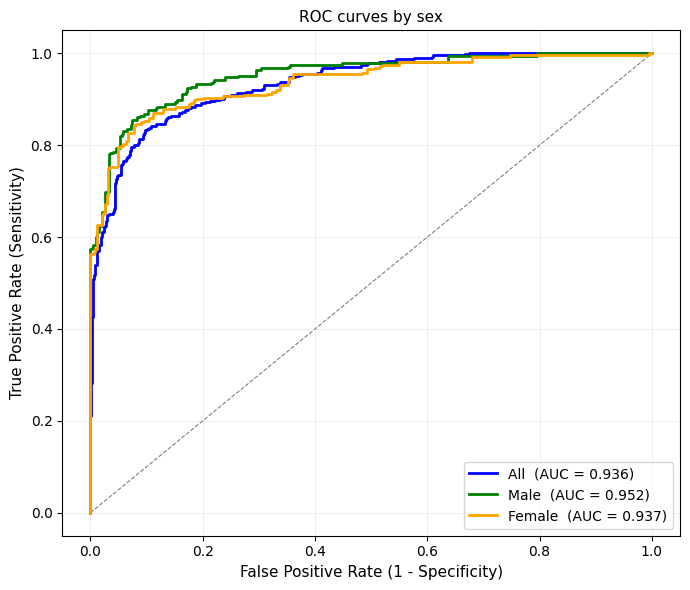

In [12]:
from utils.metrics import plot_roc_curves

plot_roc_curves(
    trainer,
    loaders_dict={
        'All':    test_loader,
        'Male':   test_loader_m,
        'Female': test_loader_f,
    }
)